In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
from pathlib import Path

out = Path("output")
out.mkdir(exist_ok=True)

In [3]:
DATA_PATH = r"C:\Users\Admin\Desktop\brca_research\brca_data_w_subtypes.csv"

df = pd.read_csv(DATA_PATH)

In [4]:
df.shape

(705, 1941)

In [5]:
df.head()

rs_CLEC3A    rs_CPB1  rs_SCGB2A2  rs_SCGB1D2    rs_TFF1   rs_MUCL1  \
0   0.892818   6.580103   14.123672   10.606501  13.189237   6.649466   
1   0.000000   3.691311   17.116090   15.517231   9.867616   9.691667   
2   3.748150   4.375255    9.658123    5.326983  12.109539  11.644307   
3   0.000000  18.235519   18.535480   14.533584  14.078992   8.913760   
4   0.000000   4.583724   15.711865   12.804521   8.881669   8.430028   

    rs_GSTM1     rs_PIP  rs_ADIPOQ   rs_ADH1B  rs_S100A7  rs_HMGCS2  \
0  10.520335  10.338490  10.248379  10.229970   0.000000   7.904609   
1   8.179522   7.911723   1.289598   1.818891   0.444879   1.289598   
2  10.517330   5.114925  11.975349  11.911437   4.126056   9.383379   
3  10.557465  13.304434   8.205059   9.211476   0.000000   4.347992   
4  12.964607   6.806517   4.294341   5.385714   0.841893   6.111570   

   rs_CYP2B7P1  rs_ANKRD30A  rs_PRAME     rs_TAT  rs_SERPINA6    rs_AGR3  \
0     8.754801     9.681176  9.363258   2.146395     1.440208  12.806272   
1     5.698288     7.885523  1.818891   2.415164     0.000000   9.798502   
2     8.630913     9.610310  4.733674  16.173177     6.791025   7.728365   
3     7.836265     9.732374  9.069201   2.974217     2.974217  11.190601   
4     7.701901    10.759198  1.370053   2.795538     8.480510  11.235454   

   rs_TFAP2B  rs_CYP4Z1   rs_DHRS2  rs_KCNJ3  rs_MYBPC1  rs_C4orf7   rs_KRT14  \
0  11.675896   2.618427   8.375717  0.892818   6.437639   6.056274  12.534884   
1  11.575206   3.039682  11.504695  3.218239   8.544378   6.833406  11.621912   
2   8.290137   2.776694  16.189475  4.987639   2.328779   2.613815  11.820689   
3   3.666688   1.386094   4.745210  4.376290   5.464894   2.442997   9.651460   
4  11.450052  10.795992  14.119632  1.755828   5.099316   6.354454   9.495218   

     rs_MUC6  rs_UGT2B11  rs_GABRP  rs_SOX10  rs_SLC30A8   rs_STAC2  \
0  10.209759    3.878617  7.533045  8.279545    8.790134  10.540809   
1   0.784336    8.881055  9.883700  8.374239    0.784336   9.061837   
2   0.000000    1.068602  8.652057  6.592058    3.897269   6.635168   
3   5.438296    3.046439  7.524791  5.397454    1.774249   6.043347   
4   4.630627    4.719441  7.295552  4.653519    2.310922   5.465498   

   rs_VSTM2A  rs_COL2A1    rs_KRT5  rs_TUSC5  rs_CEACAM5  rs_CALML5  \
0   7.265341   7.131664  12.639518  7.305826    2.892605   5.175089   
1   0.000000   3.880078  11.379258  0.000000    5.213942   4.502662   
2   3.022492  11.648423  12.322540  9.238884    8.572504   9.859580   
3   0.000000   5.503896   9.735108  4.889644   15.657112   6.606140   
4   3.393512   3.498391   9.354743  2.795538    4.783729   6.347451   

      rs_GP2   rs_GSTT1     rs_LEP  rs_FABP7  rs_C1orf64  rs_CRABP1  \
0  10.490143   0.514400   4.514034  2.715718   11.553750   4.618368   
1   7.707524   9.336238   0.000000  4.986320    8.332823   5.636787   
2   4.032409   3.932260  10.124532  3.786900    7.345917   2.328779   
3   7.306858  10.263314   1.774249  2.079771   10.874791   3.180880   
4   7.731787   9.093197   1.130008  0.481506   10.771022   4.351459   

    rs_FABP4  rs_KRT6B   rs_KLK11   rs_CST9    rs_CST1   rs_PIGR  rs_CIDEC  \
0   9.310698  8.858305  11.622206  1.836086  10.461061  7.109456  7.800338   
1   3.474086  9.006180   1.488412  0.444879   7.803937  7.088217  0.444879   
2  11.459524  9.417736   2.697551  3.117994   9.113967  6.022692  9.309617   
3   7.364504  5.904501   1.144242  2.898189   6.086809  7.118659  4.608744   
4   6.144263  7.063134   2.620727  7.037258   9.903603  7.213202  1.281134   

    rs_SYT13   rs_KLK5  rs_OLFM4  rs_HOXB13     rs_LTF    rs_TFF3   rs_MUC5B  \
0   4.146305  7.760989  6.189267   2.514097  10.219641  13.849524   9.431978   
1   3.949171  8.111446  5.626279   0.000000  11.232154  11.589648   6.303945   
2  10.090086  8.306898  2.697551   0.449746   7.810588  10.077443   6.883319   
3  12.634136  4.909144  2.211293   0.000000  12.975535  16.420502  12.010550   
4   7.473329  5.257105  4.485079   3.931976

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Columns: 1941 entries, rs_CLEC3A to histological.type
dtypes: float64(827), int64(1110), str(4)
memory usage: 10.4 MB


In [7]:
missing = (
    df.isnull()
      .sum()
      .loc[lambda x: x > 0]
      .sort_values(ascending=False)
)

missing.head(20)

HER2.Final.Status    145
PR.Status            122
ER.Status            122
dtype: int64

In [8]:
df.columns[-10:]

Index(['pp_p62.LCK.ligand', 'pp_p70S6K', 'pp_p70S6K.pT389', 'pp_p90RSK',
       'pp_p90RSK.pT359.S363', 'vital.status', 'PR.Status', 'ER.Status',
       'HER2.Final.Status', 'histological.type'],
      dtype='str')

In [9]:
target_col = "histological.type"

df[target_col].value_counts()

histological.type
infiltrating ductal carcinoma     574
infiltrating lobular carcinoma    131
Name: count, dtype: int64

In [10]:
(
    df[target_col]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

histological.type
infiltrating ductal carcinoma     81.42
infiltrating lobular carcinoma    18.58
Name: proportion, dtype: float64

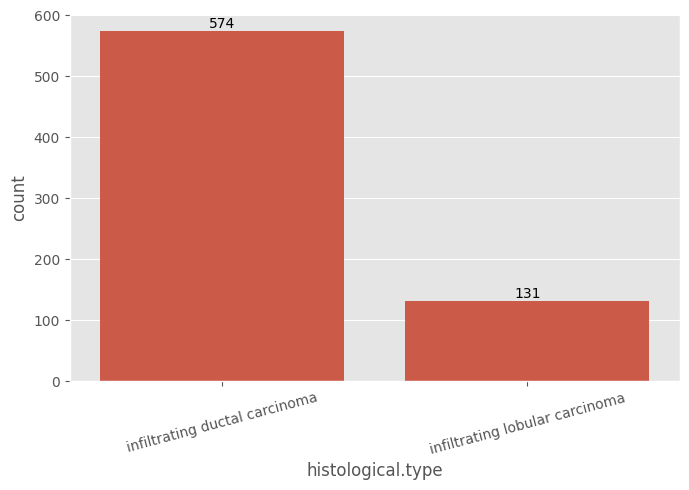

In [11]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x=target_col)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rs_CLEC3A,705.0,4.547197,4.971708,0.000000,0.000000,2.379261,8.025802,17.432087
rs_CPB1,705.0,6.487979,4.874769,0.000000,2.297602,6.002963,9.503384,20.960773
rs_SCGB2A2,705.0,9.516678,4.758348,0.000000,5.937361,10.011822,13.087360,20.978437
rs_SCGB1D2,705.0,7.351940,4.248440,0.000000,3.842758,7.701500,10.493654,19.979807
rs_TFF1,705.0,8.179439,4.291915,0.000000,5.144707,9.043774,11.536532,17.338611
...,...,...,...,...,...,...,...,...
pp_p70S6K,705.0,-0.028409,0.555587,-2.152630,-0.317636,-0.067527,0.206411,2.475027
pp_p70S6K.pT389,705.0,0.048929,0.377429,-0.751501,-0.207172,-0.039654,0.211573,1.664292
pp_p90RSK,705.0,-0.002065,0.345646,-1.334300,-0.232004,-0.010013,0.212412,1.545965
pp_p90RSK.pT359.S363,705.0,0.019180,0.291446,-1.182336,-0.147140,0.006341,0.172476,1.062551


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

pd.Series({
    "Total Columns": df.shape[1],
    "Numeric Columns": len(numeric_cols),
    "Categorical Columns": len(categorical_cols)
})

Total Columns          1941
Numeric Columns        1937
Categorical Columns       4
dtype: int64

In [14]:
target_col = "histological.type"

X = df.drop(columns=target_col)
y = df[target_col]

In [15]:
X = X.select_dtypes(include=[np.number])

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (705, 1937)
Target Shape : (705,)


In [16]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

pd.Series(label_encoder.classes_, name="Classes")

0     infiltrating ductal carcinoma
1    infiltrating lobular carcinoma
Name: Classes, dtype: str

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [18]:
print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (564, 1937)
Testing Set : (141, 1937)


In [19]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [20]:
print("Missing values in X_train :", X_train_imputed.isnull().sum().sum())
print("Missing values in X_test :", X_test_imputed.isnull().sum().sum())

Missing values in X_train : 0
Missing values in X_test : 0


In [21]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

In [22]:
print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape :", X_test_scaled.shape)

Scaled Training Shape : (564, 1937)
Scaled Testing Shape : (141, 1937)


In [23]:
X_train_scaled.head()

rs_CLEC3A   rs_CPB1  rs_SCGB2A2  rs_SCGB1D2   rs_TFF1  rs_MUCL1  \
382  -0.387835  0.154140    0.473402    0.373497 -0.758390  1.091166   
281  -0.670483 -1.082427   -0.275182   -0.131055 -0.749738  0.459202   
454   2.079396  0.625225   -1.875545   -1.666526  1.381039 -0.036759   
287   0.859648  0.278982    0.136264    0.451668 -0.257864  1.627668   
607  -0.264412  0.025733    0.468929    0.616817 -1.109076  0.984218   

     rs_GSTM1    rs_PIP  rs_ADIPOQ  rs_ADH1B  rs_S100A7  rs_HMGCS2  \
382 -0.903919  0.570397   2.149213  2.192428  -0.854678   0.946339   
281 -0.867068 -2.005053   0.767810  0.877693  -0.197766  -1.285144   
454 -0.937785  0.820605  -1.479523 -1.732803   2.119411  -0.068732   
287 -0.949256 -0.037243   0.217902  0.434791   1.929108   0.986616   
607  1.022457  0.615089   2.268907  2.178508  -0.066380   0.753678   

     rs_CYP2B7P1  rs_ANKRD30A  rs_PRAME    rs_TAT  rs_SERPINA6   rs_AGR3  \
382    -1.103982     0.722092 -1.009866  1.333433    -0.948314 -0.310642   
281    -0.553691    -1.324701  1.405709 -0.404857    -0.570398 -1.048941   
454     1.559796     1.164354  1.292863  0.409210    -0.860563  0.533545   
287    -1.001869     0.041478 -0.985405  0.105246    -0.948314  0.177678   
607    -0.690606    -0.168319 -0.461201  0.741982    -0.356743 -0.800053   

     rs_TFAP2B  rs_CYP4Z1  rs_DHRS2  rs_KCNJ3  rs_MYBPC1  rs_C4orf7  rs_KRT14  \
382   0.544620   0.076864 -0.339713 -0.762841   0.364041   1.156949  1.074090   
281  -1.177180  -0.651418 -0.305288 -0.823552  -1.083437  -1.276813 -0.485764   
454   1.216173   1.730266  0.254128 -0.972128  -0.519798  -1.276813 -1.261773   
287   0.936475   1.729971 -0.369749 -0.867264  -0.625825   0.738513  1.022532   
607  -0.085163   0.008897 -0.640414 -0.311843   0.625270   0.379946  0.929111   

      rs_MUC6  rs_UGT2B11  rs_GABRP  rs_SOX10  rs_SLC30A8  rs_STAC2  \
382  0.729849    0.280107  0.796340  1.130288   -0.880756  1.221008   
281 -0.933590   -0.732335  1.168621  1.052473   -0.771400  0.083243   
454 -1.026762   -0.006119 -0.780200 -1.192725    1.578545 -1.616388   
287 -1.152188   -0.392229  1.091740  0.767782   -0.500828  1.457702   
607  0.450744    0.637377  0.560219  0.638228   -0.884671  0.483080   

     rs_VSTM2A  rs_COL2A1   rs_KRT5  rs_TUSC5  rs_CEACAM5  rs_CALML5  \
382  -0.810100   0.399928  1.012404  2.287698   -1.417061  -0.730514   
281  -0.810100   0.112810  0.749682  0.358347   -0.478312   0.878458   
454   1.799628  -1.000108 -1.668329 -1.343481    0.981102   1.947098   
287  -0.445314  -0.584818  0.951154  0.212613    1.735930   1.410557   
607  -0.675316  -0.392825  0.794715  2.192453   -0.937964  -1.045315   

       rs_GP2  rs_GSTT1    rs_LEP  rs_FABP7  rs_C1orf64  rs_CRABP1  rs_FABP4  \
382  0.104902  0.819460  2.120003  0.735287    0.378487   0.300889  2.192859   
281 -1.667014  0.543581  0.630199  1.208352   -1.334840   0.792933  0.626376   
454  1.041144  0.385011 -1.078801 -1.033975   -0.125575   1.912023 -1.410218   
287  1.454665  0.719489  0.086201  0.189132    0.073757   0.353796  0.191376   
607 -0.803339  0.878037  2.453721  0.999031   -0.188810   0.177582  2.306025   

     rs_KRT6B  rs_KLK11   rs_CST9   rs_CST1   rs_PIGR  rs_CIDEC  rs_SYT13  \
382  0.868206  0.196937 -0.068012 -1.712223  0.823904  2.352578 -1.050890   
281  0.512167  0.581674 -1.010444 -0.416773 -1.693851  0.501052  0.541523   
454 -1.337727  1.411903 -1.010444  0.161394 -1.106464 -1.304614  0.775310   
287  0.590810  0.445220 -0.537129 -1.541439  1.587030  0.015816 -1.272681   
607  0.347644  0.700204 -0.864228 -1.466303  0.897620  2.342363 -0.748157   

      rs_KLK5  rs_OLFM4  rs_HOXB13    rs_LTF   rs_TFF3  rs_MUC5B  rs_BMPR1B  \
382  1.017124  0.528401  -0.911282  0.383086 -0.765882 -0.716027  -0.381429   
281  1.462644  0.482708  -0.779428 -1.514534 -1.638254  0.064250  -0.044480   
454 -0.126584 -1.065147   1.398778  1.829109  0.754717  1.607930   1.440427   
287  0.641255  1.129308  -0.911282  1.450231 -0.425669  1.076182  -0.281423   
607  0.7

In [24]:
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [25]:
y_pred_lr = lr.predict(X_test_scaled)

In [26]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy: {lr_accuracy:.4f}")

Accuracy: 0.8865


In [27]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

 infiltrating ductal carcinoma       0.92      0.94      0.93       115
infiltrating lobular carcinoma       0.71      0.65      0.68        26

                      accuracy                           0.89       141
                     macro avg       0.82      0.80      0.81       141
                  weighted avg       0.88      0.89      0.88       141



In [28]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

cm_lr

array([[108,   7],
       [  9,  17]])

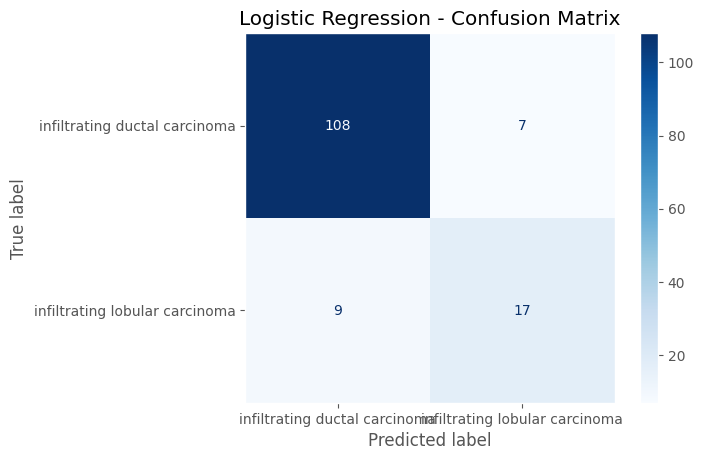

In [29]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")

plt.grid(False)

plt.show()

In [30]:
pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [lr_accuracy]
})

,Model,Accuracy
0,Logistic Regression,0.886525


In [31]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_imputed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
y_pred_rf = rf.predict(X_test_imputed)

In [33]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {rf_accuracy:.4f}")

Accuracy: 0.8794


In [34]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

 infiltrating ductal carcinoma       0.88      0.99      0.93       115
infiltrating lobular carcinoma       0.91      0.38      0.54        26

                      accuracy                           0.88       141
                     macro avg       0.89      0.69      0.74       141
                  weighted avg       0.88      0.88      0.86       141



In [35]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[114,   1],
       [ 16,  10]])

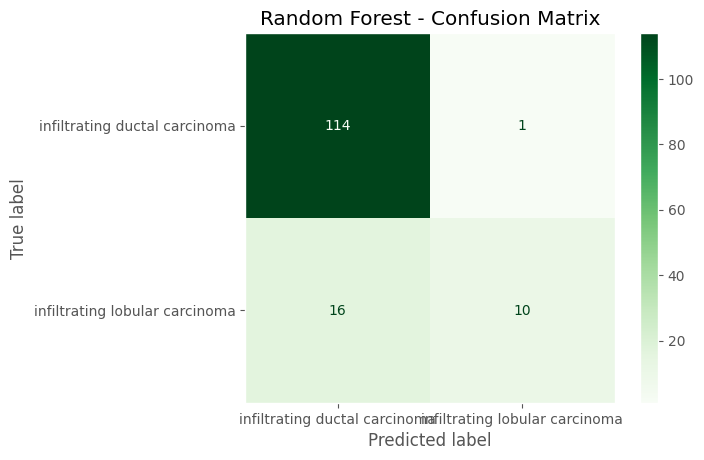

In [36]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Greens")

plt.title("Random Forest - Confusion Matrix")

plt.grid(False)

plt.show()

In [37]:
pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy]
})

,Model,Accuracy
0,Random Forest,0.879433


In [38]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_imputed, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [39]:
y_pred_xgb = xgb.predict(X_test_imputed)

In [40]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy: {xgb_accuracy:.4f}")

Accuracy: 0.9078


In [41]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

 infiltrating ductal carcinoma       0.92      0.97      0.95       115
infiltrating lobular carcinoma       0.84      0.62      0.71        26

                      accuracy                           0.91       141
                     macro avg       0.88      0.79      0.83       141
                  weighted avg       0.90      0.91      0.90       141



In [42]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

cm_xgb

array([[112,   3],
       [ 10,  16]])

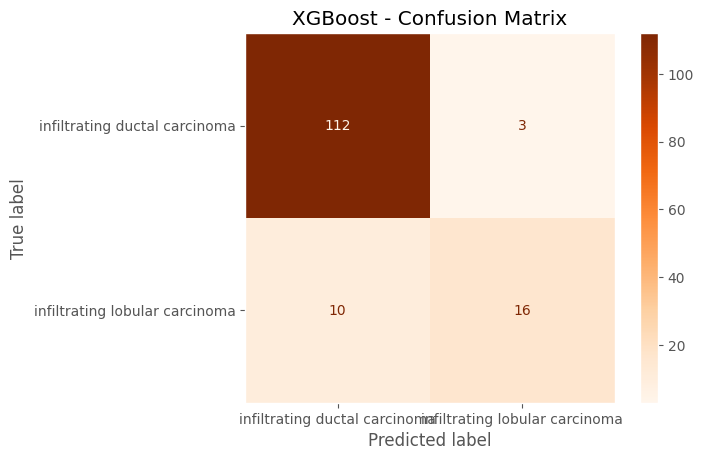

In [43]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Oranges")

plt.title("XGBoost - Confusion Matrix")
plt.grid(False)
plt.show()

In [44]:
pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [xgb_accuracy]
})

,Model,Accuracy
0,XGBoost,0.907801


In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

results.sort_values("Accuracy", ascending=False).reset_index(drop=True)

,Model,Accuracy
0,XGBoost,0.907801
1,Logistic Regression,0.886525
2,Random Forest,0.879433


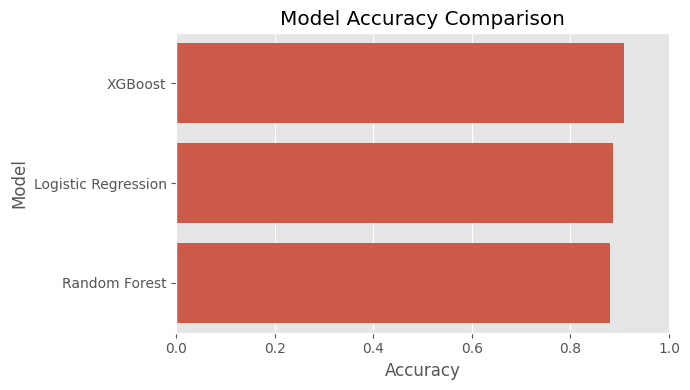

In [46]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=results.sort_values("Accuracy", ascending=False),
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1)
plt.title("Model Accuracy Comparison")

plt.tight_layout()
plt.show()

In [47]:
importances = pd.Series(
    xgb.feature_importances_,
    index=X_train_imputed.columns
).sort_values(ascending=False)

top20 = importances.head(20)

top20

rs_PLP1            0.026003
rs_CA4             0.023848
rs_CASP14          0.022350
rs_HEPN1           0.022120
rs_CCNO            0.021824
pp_AR              0.021498
pp_E.Cadherin      0.021180
rs_C20orf114       0.018408
pp_EGFR.pY1173     0.018223
rs_SCUBE2          0.016984
rs_DARC            0.015262
rs_RIMS4           0.015262
pp_Rictor          0.015160
rs_TTC36           0.013913
rs_TMEM132C        0.013757
cn_TYRP1           0.012252
rs_CAPN8           0.011946
pp_X14.3.3.beta    0.011779
rs_CITED1          0.011298
pp_beta.Catenin    0.011250
dtype: float32

In [48]:
top20.to_csv(
    out / "top20_feature_importance.csv",
    header=["Importance"]
)

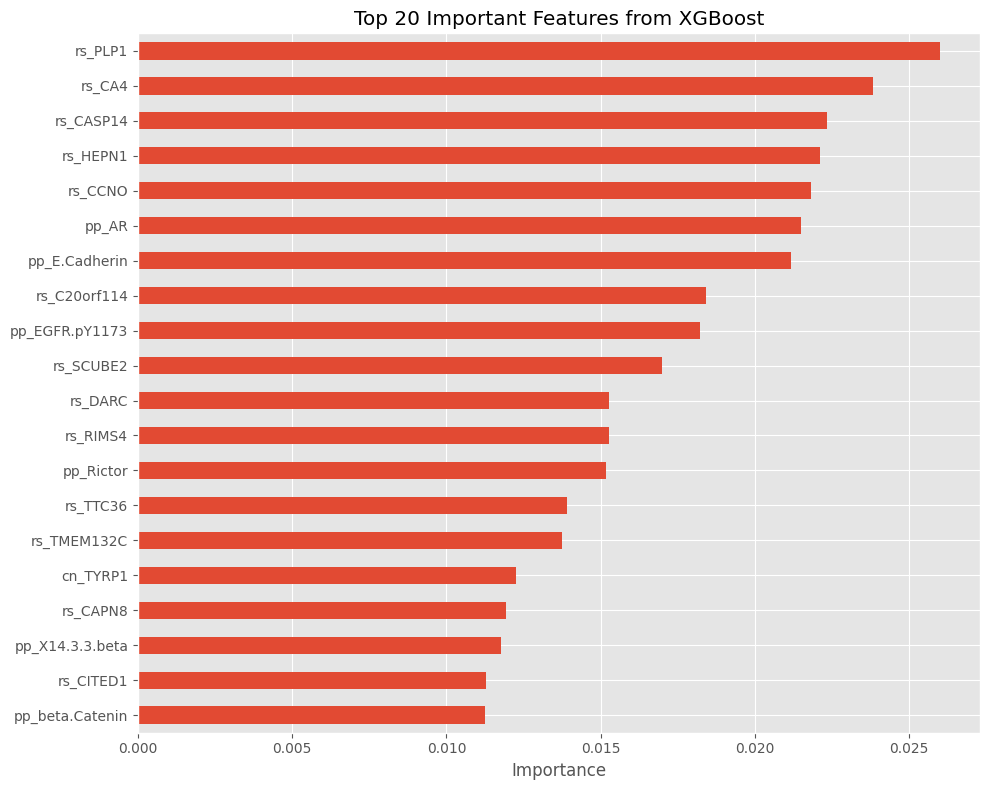

In [49]:
plt.figure(figsize=(10,8))

top20.sort_values().plot(kind="barh")

plt.title("Top 20 Important Features from XGBoost")
plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    out / "top20_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
metadata = {
    "title": "Top 20 Important Features from XGBoost",
    "caption": "Feature importance scores extracted from the trained XGBoost classifier.",
    "description": (
        "This visualization presents the twenty most important genomic "
        "features ranked according to XGBoost feature importance."
    )
}

with open(
    out / "top20_feature_importance.png.meta.json",
    "w"
) as f:
    json.dump(metadata, f, indent=4)

In [51]:
print("Files saved successfully.\n")

print(out / "top20_feature_importance.csv")
print(out / "top20_feature_importance.png")
print(out / "top20_feature_importance.png.meta.json")

Files saved successfully.

output\top20_feature_importance.csv
output\top20_feature_importance.png
output\top20_feature_importance.png.meta.json


Advanced Experimental Evaluation

In [52]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

In [53]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [54]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted"
}

In [55]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [56]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])

In [57]:
xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [58]:
lr_cv = cross_validate(
    lr_pipeline,
    X,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [59]:
rf_cv = cross_validate(
    rf_pipeline,
    X,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [60]:
xgb_cv = cross_validate(
    xgb_pipeline,
    X,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [61]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy Mean": [
        lr_cv["test_accuracy"].mean(),
        rf_cv["test_accuracy"].mean(),
        xgb_cv["test_accuracy"].mean()
    ],
    "Accuracy Std": [
        lr_cv["test_accuracy"].std(),
        rf_cv["test_accuracy"].std(),
        xgb_cv["test_accuracy"].std()
    ],
    "Precision Mean": [
        lr_cv["test_precision"].mean(),
        rf_cv["test_precision"].mean(),
        xgb_cv["test_precision"].mean()
    ],
    "Recall Mean": [
        lr_cv["test_recall"].mean(),
        rf_cv["test_recall"].mean(),
        xgb_cv["test_recall"].mean()
    ],
    "F1 Mean": [
        lr_cv["test_f1"].mean(),
        rf_cv["test_f1"].mean(),
        xgb_cv["test_f1"].mean()
    ]
})

cv_results = cv_results.round(4)

cv_results

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Logistic Regression,0.9035,0.0204,0.9008,0.9035,0.8989
1,Random Forest,0.8879,0.0263,0.8961,0.8879,0.8689
2,XGBoost,0.9291,0.0162,0.9283,0.9291,0.9264


In [62]:
cv_results.sort_values(
    by="Accuracy Mean",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,XGBoost,0.9291,0.0162,0.9283,0.9291,0.9264
1,Logistic Regression,0.9035,0.0204,0.9008,0.9035,0.8989
2,Random Forest,0.8879,0.0263,0.8961,0.8879,0.8689


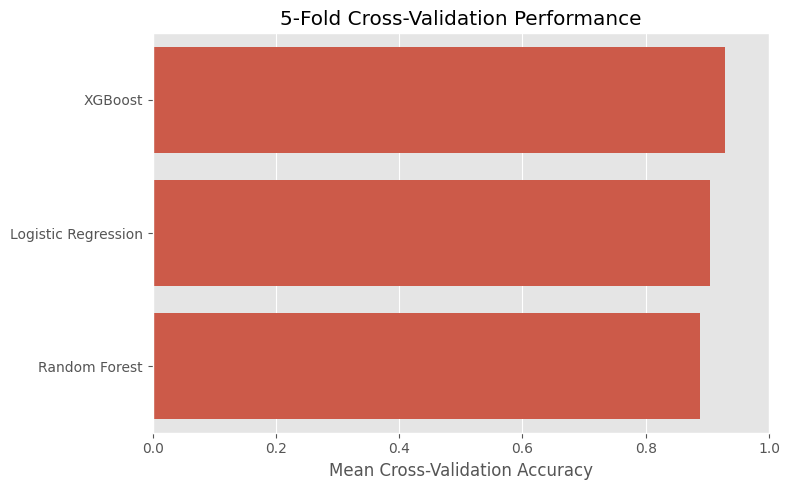

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cv_results.sort_values("Accuracy Mean", ascending=False),
    x="Accuracy Mean",
    y="Model"
)

plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("")
plt.title("5-Fold Cross-Validation Performance")

plt.xlim(0, 1)

plt.tight_layout()

plt.show()

In [64]:
from sklearn.model_selection import RandomizedSearchCV

In [65]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ["l2"]
}

In [66]:
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_grid,
    n_iter=10,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [67]:
lr_search.fit(X, y_encoded)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['liblinear', 'lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` d

In [68]:
print("Best Parameters")
lr_search.best_params_

Best Parameters


{'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 0.01}

In [69]:
print("Best Cross Validation Accuracy")
lr_search.best_score_

Best Cross Validation Accuracy


np.float64(0.9063829787234041)

In [70]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [71]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [72]:
rf_search.fit(X, y_encoded)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [73]:
rf_search.best_params_

{'model__n_estimators': 300,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 1,
 'model__max_depth': 10}

In [74]:
rf_search.best_score_

np.float64(0.9049645390070922)

In [75]:
xgb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3],
}

In [76]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [77]:
xgb_search.fit(X, y_encoded)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [78]:
xgb_search.best_params_

{'model__subsample': 0.8,
 'model__n_estimators': 200,
 'model__max_depth': 7,
 'model__learning_rate': 0.2,
 'model__gamma': 0.1,
 'model__colsample_bytree': 0.8}

In [79]:
xgb_search.best_score_

np.float64(0.9304964539007093)

In [80]:
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Best CV Accuracy": [
        lr_search.best_score_,
        rf_search.best_score_,
        xgb_search.best_score_
    ]
})

tuned_results.sort_values(
    by="Best CV Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Best CV Accuracy
0,XGBoost,0.930496
1,Logistic Regression,0.906383
2,Random Forest,0.904965


In [81]:
best_lr = lr_search.best_estimator_
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

In [82]:
y_pred_best_lr = best_lr.predict(X_test)

y_pred_best_rf = best_rf.predict(X_test)

y_pred_best_xgb = best_xgb.predict(X_test)

In [83]:
best_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_best_lr),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_best_xgb)
    ]
})

best_results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,1.000000
2,Logistic Regression,0.992908


In [84]:
print(classification_report(
    y_test,
    y_pred_best_lr,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

 infiltrating ductal carcinoma       0.99      1.00      1.00       115
infiltrating lobular carcinoma       1.00      0.96      0.98        26

                      accuracy                           0.99       141
                     macro avg       1.00      0.98      0.99       141
                  weighted avg       0.99      0.99      0.99       141



In [85]:
print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

 infiltrating ductal carcinoma       1.00      1.00      1.00       115
infiltrating lobular carcinoma       1.00      1.00      1.00        26

                      accuracy                           1.00       141
                     macro avg       1.00      1.00      1.00       141
                  weighted avg       1.00      1.00      1.00       141



In [86]:
print(classification_report(
    y_test,
    y_pred_best_xgb,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

 infiltrating ductal carcinoma       1.00      1.00      1.00       115
infiltrating lobular carcinoma       1.00      1.00      1.00        26

                      accuracy                           1.00       141
                     macro avg       1.00      1.00      1.00       141
                  weighted avg       1.00      1.00      1.00       141



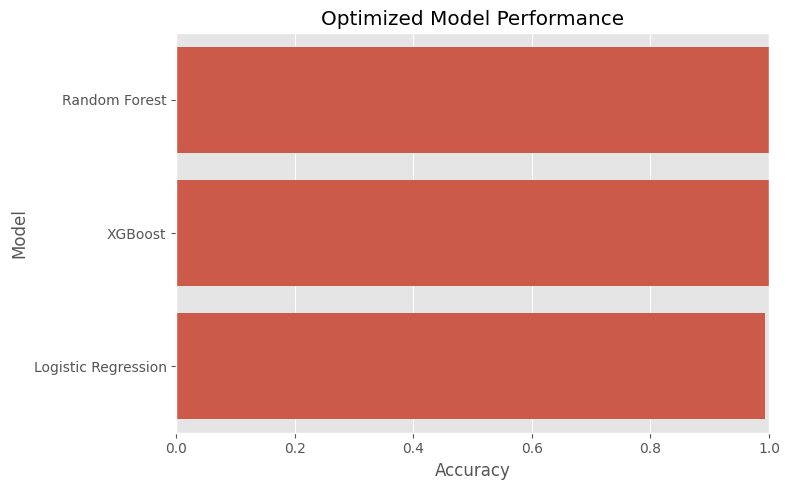

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=best_results.sort_values("Accuracy", ascending=False),
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1)
plt.title("Optimized Model Performance")

plt.tight_layout()
plt.show()

In [88]:
best_xgb_model = best_xgb.named_steps["model"]

feature_importance = pd.Series(
    best_xgb_model.feature_importances_,
    index=X.columns,
    name="Importance"
).sort_values(ascending=False)

feature_importance.head()

rs_SCUBE2             0.034279
pp_E.Cadherin         0.034100
pp_YB.1               0.024858
pp_PI3K.p110.alpha    0.023780
pp_AR                 0.023205
Name: Importance, dtype: float32

In [89]:
feature_importance.describe()

count    1937.000000
mean        0.000516
std         0.002276
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.034279
Name: Importance, dtype: float64

In [90]:
feature_importance.to_csv(
    out / "all_feature_importance.csv",
    header=True
)

In [91]:
top100_features = feature_importance.head(100).index.tolist()

len(top100_features)

100

In [92]:
top500_features = feature_importance.head(500).index.tolist()

len(top500_features)

500

In [93]:
X_top100 = X[top100_features]

X_top500 = X[top500_features]

In [94]:
print(X.shape)
print(X_top100.shape)
print(X_top500.shape)

(705, 1937)
(705, 100)
(705, 500)


Reusable Experimental Framework

In [95]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [96]:
feature_sets = {
    "All Features": None,
    "Top 100": 100,
    "Top 500": 500
}

feature_sets

{'All Features': None, 'Top 100': 100, 'Top 500': 500}

In [97]:
models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

list(models.keys())

['Logistic Regression', 'Random Forest', 'XGBoost']

In [98]:
def prepare_features(
    X_train,
    X_test,
    y_train,
    k=None
):
    """
    Select top-k features using ANOVA F-test.
    If k is None, all features are retained.
    """

    if k is None:
        return (
            X_train.copy(),
            X_test.copy(),
            None
        )

    selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector.fit_transform(
        X_train,
        y_train
    )

    X_test_selected = selector.transform(
        X_test
    )

    selected_columns = X_train.columns[
        selector.get_support()
    ]

    X_train_selected = pd.DataFrame(
        X_train_selected,
        columns=selected_columns,
        index=X_train.index
    )

    X_test_selected = pd.DataFrame(
        X_test_selected,
        columns=selected_columns,
        index=X_test.index
    )

    return (
        X_train_selected,
        X_test_selected,
        selector
    )

In [99]:
def evaluate_predictions(
    y_true,
    y_pred,
    y_prob=None
):
    """
    Calculate evaluation metrics.
    """

    results = {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

    if y_prob is not None:

        try:

            results["ROC AUC"] = roc_auc_score(
                y_true,
                y_prob[:,1]
            )

        except:

            results["ROC AUC"] = np.nan

    else:

        results["ROC AUC"] = np.nan

    return results

In [100]:
def run_experiment(
    model_name,
    pipeline,
    X,
    y,
    feature_count
):
    """
    Run one complete experiment.
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    X_train, X_test, selector = prepare_features(
        X_train,
        X_test,
        y_train,
        feature_count
    )

    model = clone(
        pipeline
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = None

    if hasattr(
        model,
        "predict_proba"
    ):
        probabilities = model.predict_proba(
            X_test
        )

    scores = evaluate_predictions(
        y_test,
        predictions,
        probabilities
    )

    scores["Model"] = model_name

    scores["Feature Set"] = (
        "All Features"
        if feature_count is None
        else f"Top {feature_count}"
    )

    return scores

In [101]:
test_run = run_experiment(
    model_name="Logistic Regression",
    pipeline=models["Logistic Regression"],
    X=X,
    y=y_encoded,
    feature_count=100
)

pd.Series(test_run)

Accuracy                  0.900709
Precision                 0.895715
Recall                    0.900709
F1 Score                  0.895496
ROC AUC                    0.93612
Model          Logistic Regression
Feature Set                Top 100
dtype: object

In [102]:
experiment_results = []

In [103]:
for feature_name, feature_count in feature_sets.items():

    print(f"\nRunning {feature_name}")

    for model_name, pipeline in models.items():

        print(f"   {model_name}")

        result = run_experiment(
            model_name=model_name,
            pipeline=pipeline,
            X=X,
            y=y_encoded,
            feature_count=feature_count
        )

        experiment_results.append(result)


Running All Features
   Logistic Regression
   Random Forest
   XGBoost

Running Top 100
   Logistic Regression
   Random Forest
   XGBoost

Running Top 500
   Logistic Regression
   Random Forest
   XGBoost


In [104]:
experiment_results = pd.DataFrame(experiment_results)

experiment_results

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Model,Feature Set
0,0.893617,0.887642,0.893617,0.886914,0.914716,Logistic Regression,All Features
1,0.900709,0.903342,0.900709,0.888277,0.896656,Random Forest,All Features
2,0.900709,0.896327,0.900709,0.893352,0.957860,XGBoost,All Features
3,0.900709,0.895715,0.900709,0.895496,0.936120,Logistic Regression,Top 100
4,0.907801,0.904032,0.907801,0.901992,0.923746,Random Forest,Top 100
5,0.886525,0.881172,0.886525,0.882767,0.946823,XGBoost,Top 100
6,0.929078,0.927636,0.929078,0.925354,0.933445,Logistic Regression,Top 500
7,0.900709,0.896327,0.900709,0.893352,0.917057,Random Forest,Top 500
8,0.914894,0.911676,0.914894,0.910425,0.960201,XGBoost,Top 500


In [105]:
experiment_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Model,Feature Set
6,0.929078,0.927636,0.929078,0.925354,0.933445,Logistic Regression,Top 500
8,0.914894,0.911676,0.914894,0.910425,0.960201,XGBoost,Top 500
4,0.907801,0.904032,0.907801,0.901992,0.923746,Random Forest,Top 100
3,0.900709,0.895715,0.900709,0.895496,0.936120,Logistic Regression,Top 100
1,0.900709,0.903342,0.900709,0.888277,0.896656,Random Forest,All Features
7,0.900709,0.896327,0.900709,0.893352,0.917057,Random Forest,Top 500
2,0.900709,0.896327,0.900709,0.893352,0.957860,XGBoost,All Features
0,0.893617,0.887642,0.893617,0.886914,0.914716,Logistic Regression,All Features
5,0.886525,0.881172,0.886525,0.882767,0.946823,XGBoost,Top 100


In [106]:
experiment_results.to_csv(
    out / "feature_selection_experiments.csv",
    index=False
)

Permutation Feature Importance

In [107]:
from sklearn.inspection import permutation_importance

In [108]:
final_model = clone(best_xgb)

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [109]:
perm_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [110]:
perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

perm_importance.head(20)

pp_E.Cadherin        0.067730
pp_AR                0.013475
mu_CDH1              0.006738
rs_PCK1              0.001418
pp_beta.Catenin      0.001418
vital.status         0.000000
pp_eIF4G             0.000000
pp_eIF4E             0.000000
pp_eEF2K             0.000000
pp_eEF2              0.000000
pp_PRAS40.pT246      0.000000
pp_p27               0.000000
pp_p27.pT157         0.000000
pp_p27.pT198         0.000000
pp_p38.MAPK          0.000000
pp_p38.pT180.Y182    0.000000
pp_p53               0.000000
pp_p62.LCK.ligand    0.000000
pp_p70S6K            0.000000
pp_p70S6K.pT389      0.000000
dtype: float64

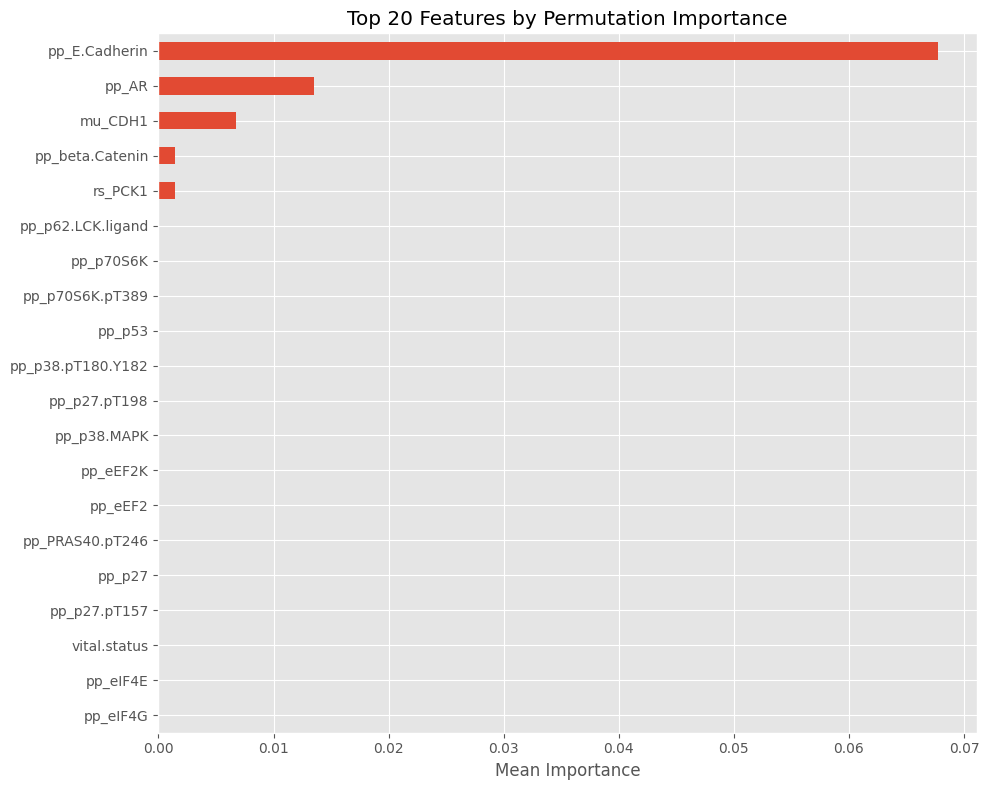

In [111]:
plt.figure(figsize=(10, 8))

perm_importance.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Features by Permutation Importance")
plt.xlabel("Mean Importance")

plt.tight_layout()
plt.show()

SHAP Explainability Analysis

In [112]:
import shap

In [113]:
shap.initjs()

In [114]:
xgb_pipeline = clone(best_xgb)

In [115]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [116]:
xgb_model = xgb_pipeline.named_steps["model"]

In [117]:
preprocessing = Pipeline(
    xgb_pipeline.steps[:-1]
)

In [118]:
X_train_processed = preprocessing.transform(X_train)
X_test_processed = preprocessing.transform(X_test)

In [119]:
feature_names = X_train.columns.tolist()

len(feature_names)

1937

In [120]:
explainer = shap.TreeExplainer(xgb_model)

In [121]:
shap_values = explainer.shap_values(X_test_processed)

In [122]:
type(shap_values)

numpy.ndarray

 SHAP Summary Plot

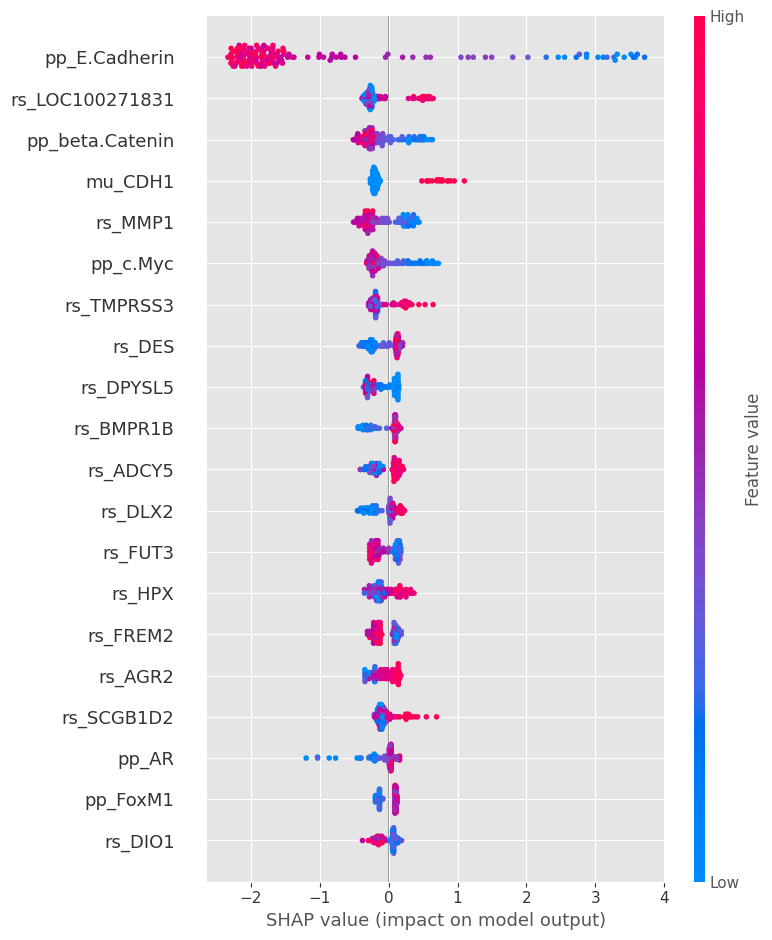

In [123]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    out / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SHAP Beeswarm Plot

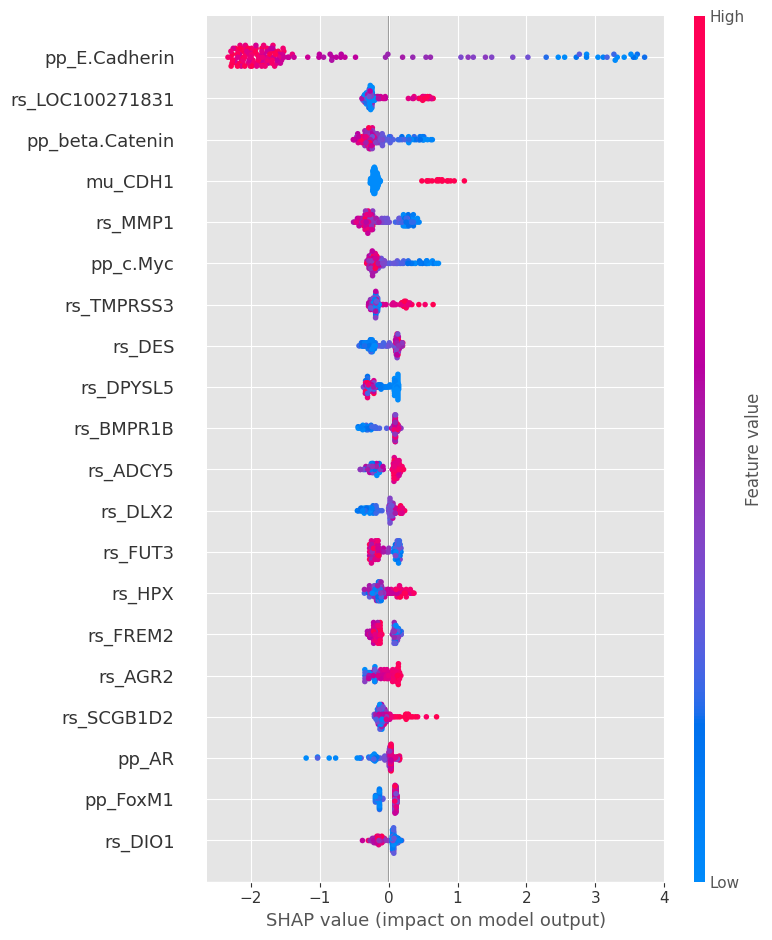

In [124]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="dot",
    show=False
)

plt.tight_layout()

plt.savefig(
    out / "shap_beeswarm_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SHAP Feature Importance

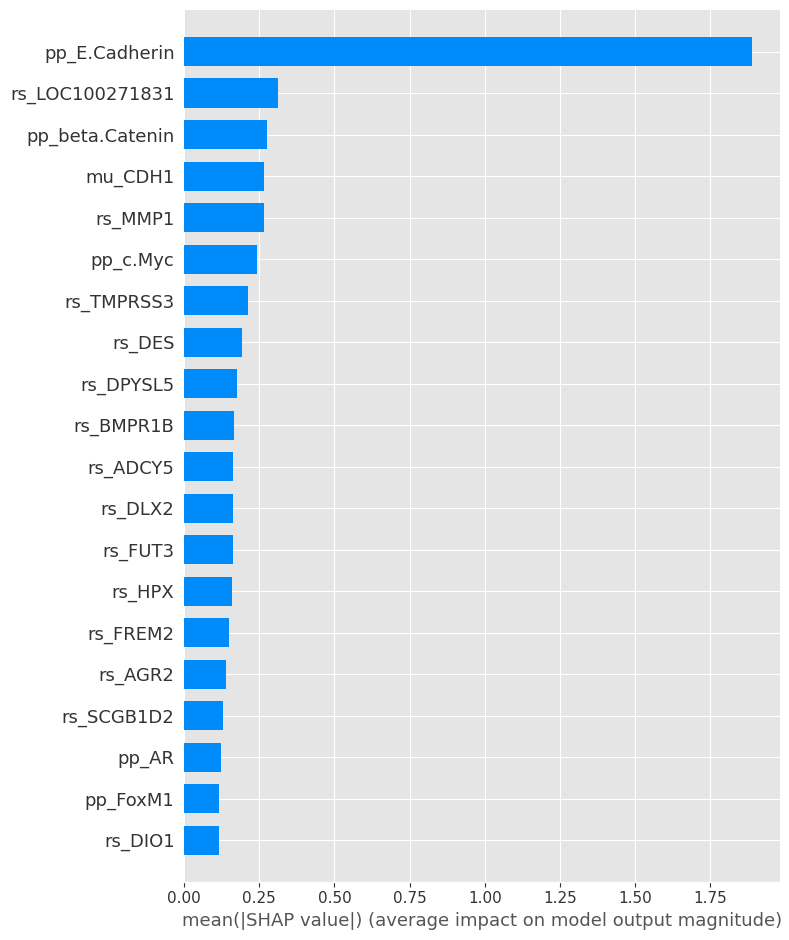

In [125]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    out / "shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [126]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

shap_importance.head(20)

,Feature,Mean_SHAP
1782,pp_E.Cadherin,1.887874
284,rs_LOC100271831,0.312460
1909,pp_beta.Catenin,0.275461
1470,mu_CDH1,0.265433
101,rs_MMP1,0.264798
1915,pp_c.Myc,0.243043
352,rs_TMPRSS3,0.212783
351,rs_DES,0.191689
602,rs_DPYSL5,0.174760
57,rs_BMPR1B,0.166428


In [127]:
shap_importance.to_csv(
    out / "shap_feature_importance.csv",
    index=False
)

Consensus Biomarker Discovery

In [128]:
xgb_importance = feature_importance.reset_index()
xgb_importance.columns = ["Feature", "XGB_Importance"]

perm_df = perm_importance.reset_index()
perm_df.columns = ["Feature", "Permutation_Importance"]

shap_df = shap_importance.copy()
shap_df.columns = ["Feature", "SHAP_Importance"]

In [129]:
consensus = (
    xgb_importance
    .merge(perm_df, on="Feature")
    .merge(shap_df, on="Feature")
)

consensus.head()

,Feature,XGB_Importance,Permutation_Importance,SHAP_Importance
0,rs_SCUBE2,0.034279,-0.006028,0.106215
1,pp_E.Cadherin,0.034100,0.067730,1.887874
2,pp_YB.1,0.024858,0.000000,0.049627
3,pp_PI3K.p110.alpha,0.023780,0.000000,0.000000
4,pp_AR,0.023205,0.013475,0.121258


In [130]:
consensus["XGB_Rank"] = (
    consensus["XGB_Importance"]
    .rank(ascending=False, method="min")
)

consensus["Permutation_Rank"] = (
    consensus["Permutation_Importance"]
    .rank(ascending=False, method="min")
)

consensus["SHAP_Rank"] = (
    consensus["SHAP_Importance"]
    .rank(ascending=False, method="min")
)

In [131]:
consensus["Average_Rank"] = (
    consensus[
        [
            "XGB_Rank",
            "Permutation_Rank",
            "SHAP_Rank"
        ]
    ]
    .mean(axis=1)
)

In [132]:
consensus = consensus.sort_values(
    by="Average_Rank"
)

consensus.head(20)

,Feature,XGB_Importance,Permutation_Importance,SHAP_Importance,XGB_Rank,Permutation_Rank,SHAP_Rank,Average_Rank
1,pp_E.Cadherin,0.034100,0.067730,1.887874,2.0,1.0,1.0,1.333333
8,mu_CDH1,0.017582,0.006738,0.265433,9.0,3.0,4.0,5.333333
4,pp_AR,0.023205,0.013475,0.121258,5.0,2.0,18.0,8.333333
40,pp_beta.Catenin,0.006489,0.001418,0.275461,41.0,4.0,3.0,16.000000
2,pp_YB.1,0.024858,0.000000,0.049627,3.0,6.0,62.0,23.666667
5,rs_LY6D,0.023167,0.000000,0.041154,6.0,6.0,74.0,28.666667
25,pp_eEF2,0.008806,0.000000,0.055219,26.0,6.0,58.0,30.000000
53,rs_PLCH1,0.005555,0.000000,0.080696,54.0,6.0,35.0,31.666667
78,rs_FREM2,0.003788,0.000000,0.150026,79.0,6.0,15.0,33.333333
70,rs_LOC642587,0.004322,0.000000,0.097996,71.0,6.0,29.0,35.333333


In [133]:
consensus.to_csv(
    out / "consensus_biomarkers.csv",
    index=False
)

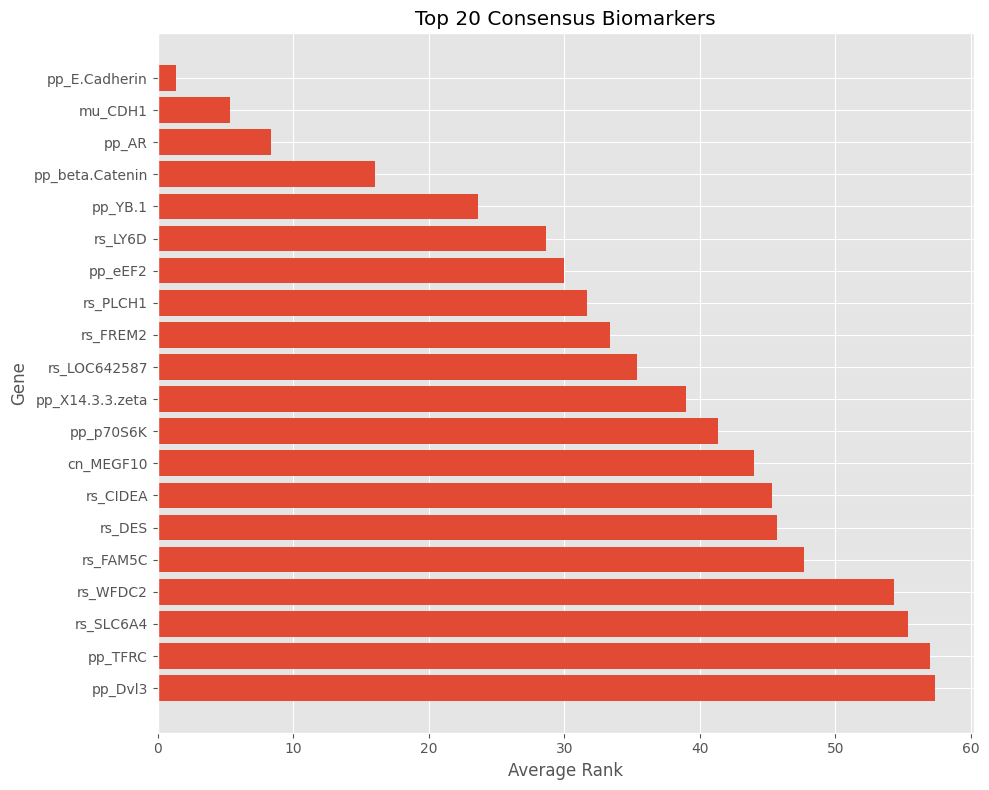

In [134]:
top20 = consensus.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"][::-1],
    top20["Average_Rank"][::-1]
)

plt.xlabel("Average Rank")
plt.ylabel("Gene")

plt.title("Top 20 Consensus Biomarkers")

plt.tight_layout()

plt.savefig(
    out / "consensus_biomarkers.png",
    dpi=300
)

plt.show()

Cross-Validation Based Model Evaluation

In [135]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

In [136]:
# 5-Fold Stratified Cross Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [137]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted",
    "roc_auc": "roc_auc_ovr_weighted"
}

In [138]:
print(X.shape)
print(y.shape)

(705, 1937)
(705,)


Cross Validation Performance Analysis

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

cv_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [142]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Original Classes:")
print(le.classes_)

print("\nEncoded Labels:")
print(np.unique(y_encoded))

Original Classes:
['infiltrating ductal carcinoma' 'infiltrating lobular carcinoma']

Encoded Labels:
[0 1]


In [143]:
cv_results = []

for model_name, model in cv_models.items():

    scores = cross_validate(
        estimator=model,
        X=X,
        y=y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy Mean": np.mean(scores["test_accuracy"]),
        "Accuracy Std": np.std(scores["test_accuracy"]),

        "Precision Mean": np.mean(scores["test_precision"]),
        "Recall Mean": np.mean(scores["test_recall"]),
        "F1 Mean": np.mean(scores["test_f1"]),
        "ROC AUC Mean": np.mean(scores["test_roc_auc"])
    })

cv_results = pd.DataFrame(cv_results)

cv_results

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC AUC Mean
0,Logistic Regression,0.886525,0.019552,0.882823,0.886525,0.883161,0.909134
1,Random Forest,0.879433,0.010030,0.888641,0.879433,0.857150,0.922589
2,XGBoost,0.921986,0.014877,0.920223,0.921986,0.919385,0.946100


In [144]:
from scipy.stats import wilcoxon

In [145]:
cv_scores = {}

for model_name, model in cv_models.items():

    scores = cross_validate(
        estimator=model,
        X=X,
        y=y_encoded,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_scores[model_name] = scores["test_score"]

cv_scores

{'Logistic Regression': array([0.85106383, 0.90070922, 0.90070922, 0.90070922, 0.87943262]),
 'Random Forest': array([0.86524823, 0.89361702, 0.87234043, 0.88652482, 0.87943262]),
 'XGBoost': array([0.89361702, 0.93617021, 0.92907801, 0.92907801, 0.92198582])}

In [146]:
comparisons = [
    ("Logistic Regression", "Random Forest"),
    ("Logistic Regression", "XGBoost"),
    ("Random Forest", "XGBoost")
]

results = []

for model1, model2 in comparisons:

    stat, p = wilcoxon(
        cv_scores[model1],
        cv_scores[model2]
    )

    results.append({
        "Comparison": f"{model1} vs {model2}",
        "Statistic": stat,
        "P-value": p,
        "Significant (p<0.05)": p < 0.05
    })

significance_df = pd.DataFrame(results)

significance_df

,Comparison,Statistic,P-value,Significant (p<0.05)
0,Logistic Regression vs Random Forest,2.5,0.5000,False
1,Logistic Regression vs XGBoost,0.0,0.0625,False
2,Random Forest vs XGBoost,0.0,0.0625,False


In [147]:
from scipy import stats

In [148]:
confidence_results = []

for model_name, scores in cv_scores.items():

    mean = np.mean(scores)

    std = np.std(scores, ddof=1)

    n = len(scores)

    sem = stats.sem(scores)

    ci = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=mean,
        scale=sem
    )

    confidence_results.append({
        "Model": model_name,
        "Mean Accuracy": mean,
        "Std": std,
        "95% CI Lower": ci[0],
        "95% CI Upper": ci[1]
    })

confidence_df = pd.DataFrame(confidence_results)

confidence_df

,Model,Mean Accuracy,Std,95% CI Lower,95% CI Upper
0,Logistic Regression,0.886525,0.021860,0.859383,0.913667
1,Random Forest,0.879433,0.011214,0.865509,0.893356
2,XGBoost,0.921986,0.016633,0.901334,0.942638


In [149]:
publication_table = cv_results.copy()

publication_table["95% Confidence Interval"] = (
    confidence_df["95% CI Lower"].round(4).astype(str)
    + " - " +
    confidence_df["95% CI Upper"].round(4).astype(str)
)

publication_table = publication_table[[
    "Model",
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean",
    "ROC AUC Mean",
    "95% Confidence Interval"
]]

publication_table = publication_table.round(4)

publication_table

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC AUC Mean,95% Confidence Interval
0,Logistic Regression,0.8865,0.8828,0.8865,0.8832,0.9091,0.8594 - 0.9137
1,Random Forest,0.8794,0.8886,0.8794,0.8572,0.9226,0.8655 - 0.8934
2,XGBoost,0.9220,0.9202,0.9220,0.9194,0.9461,0.9013 - 0.9426
